In [1]:
!pip install roboflow
!pip install ultralytics==8.3.148 ultralytics-thop==2.0.14 torch==2.7.0 torchvision==0.22.0 torchaudio==2.7.0 numpy==1.26.4 opencv-python==4.11.0.86 matplotlib==3.10.1 tqdm==4.67.1 PyYAML==6.0.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 35.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 61.6 MB/s eta 0:00:00ta 0:00:01
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquer

In [4]:
from roboflow import Roboflow
from ultralytics import YOLO
import os

In [6]:
import os
import shutil

# Path to the uploaded dataset
uploaded_dataset_path = "/kaggle/input/solar-panel-normal-or-defect"

# Path to save dataset for training
output_path = "/kaggle/working/elpv-crack-detection"

# Remove existing output folder if exists
if os.path.exists(output_path):
    shutil.rmtree(output_path)

# Copy dataset to output folder
shutil.copytree(uploaded_dataset_path, output_path)

print(f"Dataset copied to: {output_path}")



Dataset copied to: /kaggle/working/elpv-crack-detection


In [7]:
import yaml

yaml_path = "/kaggle/working/elpv-crack-detection/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print("Original classes:", data["names"])
print("Total classes:", len(data["names"]))


Original classes: ['defect100', 'defect30', 'defect60', 'normal']
Total classes: 4


In [8]:
import yaml

old_yaml_path = "/kaggle/working/elpv-crack-detection/data.yaml"
new_yaml_path = "/kaggle/working/elpv-crack-detection/data_2.yaml"

with open(old_yaml_path, "r") as f:
    data = yaml.safe_load(f)

# Modify the classes
new_data = data.copy()
new_data["names"] = ["defect", "normal"]
new_data["nc"] = 2

# Save the new YAML
with open(new_yaml_path, "w") as f:
    yaml.dump(new_data, f)

print("New data.yaml created at:", new_yaml_path)
print(new_data)


New data.yaml created at: /kaggle/working/elpv-crack-detection/data_2.yaml
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 2, 'names': ['defect', 'normal'], 'roboflow': {'workspace': 'insulator-detection-qneio', 'project': 'elpv-crack-detection', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/insulator-detection-qneio/elpv-crack-detection/dataset/1'}}


In [9]:
import os

label_dir = "/kaggle/working/elpv-crack-detection"   # adjust if different

for split in ["train", "valid", "test"]:
    path = os.path.join(label_dir, split)
    for fname in os.listdir(path):
        if not fname.endswith(".txt"):
            continue
        
        fpath = os.path.join(path, fname)

        with open(fpath, "r") as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            cls = int(parts[0])

            # remap class IDs
            if cls in [0, 1, 2]:     # all defect classes
                new_cls = 0
            elif cls == 3:           # normal
                new_cls = 1
            else:
                raise ValueError(f"Unexpected classID {cls} in {fpath}")

            parts[0] = str(new_cls)
            new_lines.append(" ".join(parts) + "\n")

        with open(fpath, "w") as f:
            f.writelines(new_lines)

print("All labels successfully remapped!")


All labels successfully remapped!


In [10]:
# Load the model (YOLOv8n, YOLOv8s, YOLOv8m, YOLOv8l, YOLOv8x available)
model = YOLO('yolov8n.pt')  # or use yolov8s.pt for better accuracy

# Train the model
model.train(
    data='/kaggle/working/elpv-crack-detection/data_2.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    project='solar_panel_defect_detection_yolov8',
    name='yolov8_el_inspection',
    verbose=True
)

100%|██████████| 6.25M/6.25M [00:00<00:00, 277MB/s]

New https://pypi.org/project/ultralytics/8.3.228 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.3.148 🚀 Python-3.11.13 torch-2.7.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/elpv-crack-detection/data_2.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_el_inspection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

100%|██████████| 755k/755k [00:00<00:00, 171MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

                   all        200        200      0.748      0.888      0.886      0.886



50 epochs completed in 0.132 hours.
Optimizer stripped from solar_panel_defect_detection_yolov8/yolov8_el_inspection/weights/last.pt, 6.2MB
Optimizer stripped from solar_panel_defect_detection_yolov8/yolov8_el_inspection/weights/best.pt, 6.2MB

Validating solar_panel_defect_detection_yolov8/yolov8_el_inspection/weights/best.pt...
Ultralytics 8.3.148 🚀 Python-3.11.13 torch-2.7.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.12it/s]
invalid value encountered in less
invalid value encountered in less


                   all        200        200       0.76      0.885      0.891      0.891
                defect        140        140      0.875      0.886      0.964      0.964
                normal         60         60      0.646      0.883      0.819      0.819
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to solar_panel_defect_detection_yolov8/yolov8_el_inspection


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dcc23119f50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [12]:
model = YOLO("yolov9t.pt") 

model.train(
    data="/kaggle/working/elpv-crack-detection/data_2.yaml",  # dataset path
    epochs=50,
    imgsz=640,
    batch=16,
    project='solar_panel_defect_detection_yolov9',
    name='yolov9_el_inspection',
    verbose=True
)

New https://pypi.org/project/ultralytics/8.3.228 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.148 🚀 Python-3.11.13 torch-2.7.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/elpv-crack-detection/data_2.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9t.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov9_el_inspectio

train: Scanning /kaggle/working/elpv-crack-detection/train/labels.cache... 1837 images, 0 backgrounds, 1122 corrupt: 100%|██████████| 1837/1837 [00:00<?, ?it/s]

train: /kaggle/working/elpv-crack-detection/train/images/cell0004_png_jpg.rf.8c644990be942104f8f620f1e45cb21d.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
train: /kaggle/working/elpv-crack-detection/train/images/cell0009_png_jpg.rf.8eb0dd7d1c596932f2804e610b29b1b0.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
train: /kaggle/working/elpv-crack-detection/train/images/cell0011_png_jpg.rf.e83e35b6ec78b7df9ab639cca43c5594.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
train: /kaggle/working/elpv-crack-detection/train/images/cell0060_png_jpg.rf.65d3ca25cbdeb042287e4697fd5837ff.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
train: /kaggle/working/elpv-crack-detection/train/images/cell0061_png_jpg.rf.ffafbd6218feea3f5381338bfc360358.jpg: ignor

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 309.4±218.5 MB/s, size: 25.7 KB)


val: Scanning /kaggle/working/elpv-crack-detection/valid/labels.cache... 525 images, 0 backgrounds, 325 corrupt: 100%|██████████| 525/525 [00:00<?, ?it/s]

...

                   all        200        200      0.719      0.905      0.876      0.872



50 epochs completed in 0.224 hours.
Optimizer stripped from solar_panel_defect_detection_yolov9/yolov9_el_inspection2/weights/last.pt, 4.6MB
Optimizer stripped from solar_panel_defect_detection_yolov9/yolov9_el_inspection2/weights/best.pt, 4.6MB

Validating solar_panel_defect_detection_yolov9/yolov9_el_inspection2/weights/best.pt...
Ultralytics 8.3.148 🚀 Python-3.11.13 torch-2.7.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv9t summary (fused): 197 layers, 1,971,174 parameters, 0 gradients, 7.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.89it/s]
invalid value encountered in less
invalid value encountered in less


                   all        200        200      0.724      0.908      0.884      0.884
                defect        140        140      0.863      0.899      0.952      0.952
                normal         60         60      0.585      0.917      0.816      0.816
Speed: 0.2ms preprocess, 2.7ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to solar_panel_defect_detection_yolov9/yolov9_el_inspection2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dcb1c330f90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [14]:
from ultralytics import YOLO

# Load trained model
model = YOLO("/kaggle/working/solar_panel_defect_detection_yolov8/yolov8_el_inspection/weights/best.pt")

# Predict image
image_path = "/kaggle/working/elpv-crack-detection/test/images/cell0005_png_jpg.rf.b774602c4e6ad1e82f4cfa60bd259996.jpg"
results = model.predict(image_path, conf=0.25, show=True)

# Classify logic
def classify_solar_panel(result):
    names = model.names  # {0: normal, 1: defect}
    for box in result.boxes:
        cls_id = int(box.cls[0])
        if names[cls_id] == "defect":
            return "Defected"
    return "Normal"

# Output
print("Solar Panel Status:", classify_solar_panel(results[0]))


WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/1 /kaggle/working/elpv-crack-detection/test/images/cell0005_png_jpg.rf.b774602c4e6ad1e82f4cfa60bd259996.jpg: 640x640 2 defects, 6.2ms
Speed: 1.7ms preprocess, 6.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Solar Panel Status: Defected


In [15]:
from ultralytics import YOLO

# Load trained model
model = YOLO("/kaggle/working/solar_panel_defect_detection_yolov8/yolov8_el_inspection/weights/best.pt")

# Predict image
image_path = "/kaggle/working/elpv-crack-detection/test/images/cell0090_png_jpg.rf.4d6f8e27f0222b82f4601bec73ec4328.jpg"
results = model.predict(image_path, conf=0.25, show=True)

# Classify logic
def classify_solar_panel(result):
    names = model.names  # {0: normal, 1: defect}
    for box in result.boxes:
        cls_id = int(box.cls[0])
        if names[cls_id] == "defect":
            return "Defected"
    return "Normal"

# Output
print("Solar Panel Status:", classify_solar_panel(results[0]))



image 1/1 /kaggle/working/elpv-crack-detection/test/images/cell0090_png_jpg.rf.4d6f8e27f0222b82f4601bec73ec4328.jpg: 640x640 1 normal, 5.3ms
Speed: 1.3ms preprocess, 5.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Solar Panel Status: Normal



image 1/1 /kaggle/working/elpv-crack-detection/test/images/cell0090_png_jpg.rf.4d6f8e27f0222b82f4601bec73ec4328.jpg: 640x640 1 normal, 5.6ms
Speed: 1.5ms preprocess, 5.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Detected Objects:
Class: normal, Confidence: 0.71, Box: [0.0, 0.742431640625, 640.0, 639.103515625]


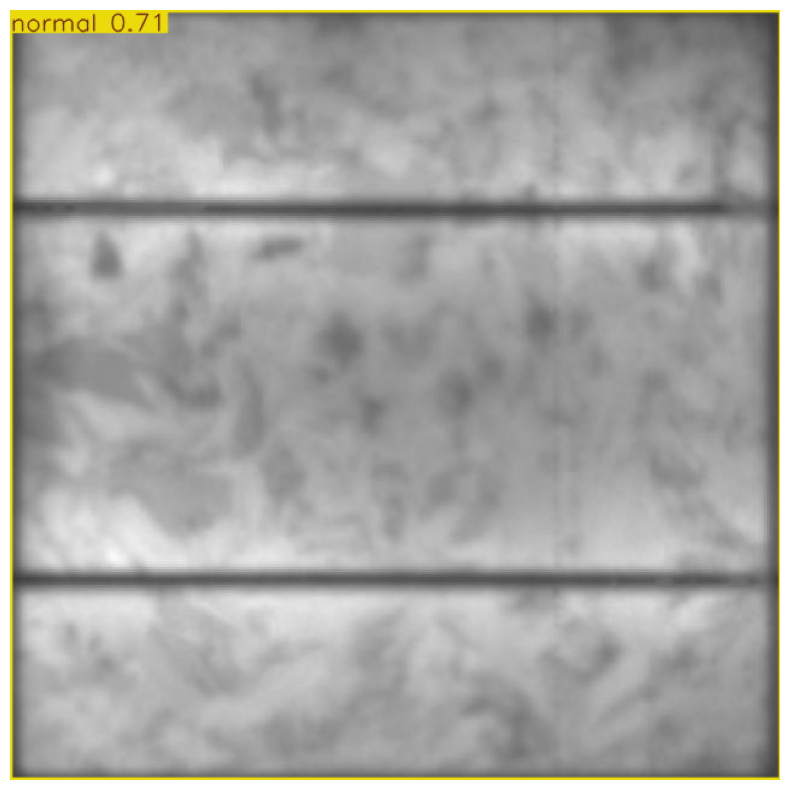

Solar Panel Status: Normal


In [16]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load trained model
model = YOLO("/kaggle/working/solar_panel_defect_detection_yolov8/yolov8_el_inspection/weights/best.pt")

# Predict image
image_path = "/kaggle/working/elpv-crack-detection/test/images/cell0090_png_jpg.rf.4d6f8e27f0222b82f4601bec73ec4328.jpg"
results = model.predict(image_path, conf=0.25)

# Classify logic with details and display
def classify_and_show(result):
    names = model.names  # {0: normal, 1: defect}
    defect_found = False

    print("Detected Objects:")
    for box in result.boxes:
        cls_id = int(box.cls[0])
        label = names[cls_id]
        conf = float(box.conf[0])
        coords = box.xyxy[0].tolist()  # [x1, y1, x2, y2]
        print(f"Class: {label}, Confidence: {conf:.2f}, Box: {coords}")
        if label == "defect":
            defect_found = True

    # Display image with predictions
    img_with_boxes = result.plot()  # returns numpy array with boxes drawn
    plt.figure(figsize=(10,10))
    plt.imshow(img_with_boxes)
    plt.axis('off')
    plt.show()

    return "Defected" if defect_found else "Normal"

# Run classification & display
status = classify_and_show(results[0])
print("Solar Panel Status:", status)



image 1/1 /kaggle/working/elpv-crack-detection/test/images/cell0005_png_jpg.rf.b774602c4e6ad1e82f4cfa60bd259996.jpg: 640x640 2 defects, 5.3ms
Speed: 1.4ms preprocess, 5.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Highest Confidence Detection:
Class: defect, Confidence: 0.92, Box: [0.0, 1.19537353515625, 637.6907958984375, 567.502685546875]


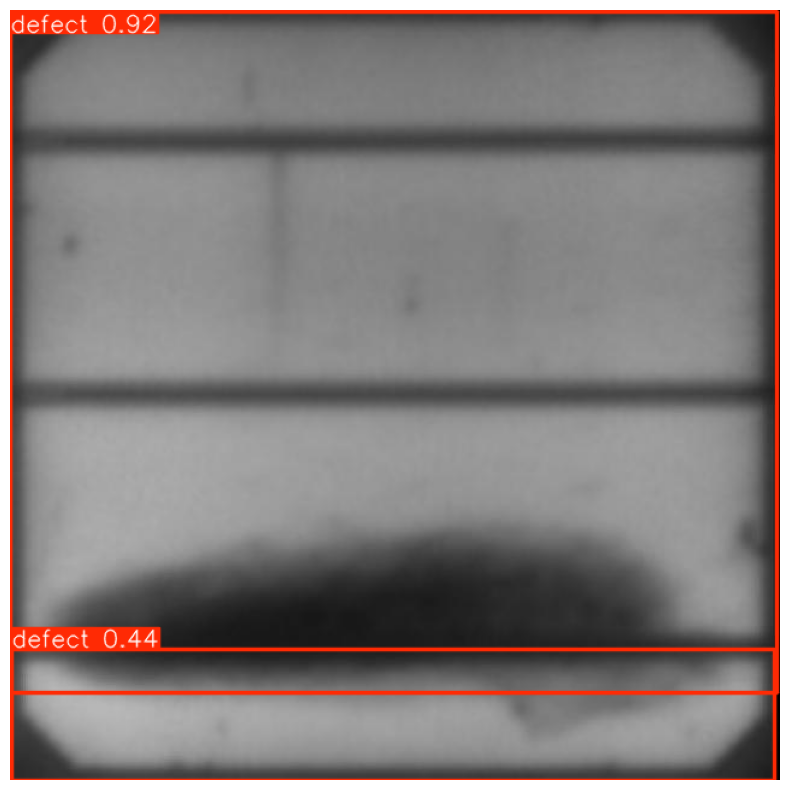

Solar Panel Status: Defected


In [17]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np

# Load trained model
model = YOLO("/kaggle/working/solar_panel_defect_detection_yolov8/yolov8_el_inspection/weights/best.pt")

# Predict image
image_path = "/kaggle/working/elpv-crack-detection/test/images/cell0005_png_jpg.rf.b774602c4e6ad1e82f4cfa60bd259996.jpg"
results = model.predict(image_path, conf=0.25)

# Classify logic with highest-confidence detection
def classify_highest_confidence(result):
    names = model.names  # {0: normal, 1: defect}
    
    if len(result.boxes) == 0:
        print("No objects detected.")
        return "Normal"

    # Find box with highest confidence
    confs = [float(box.conf[0]) for box in result.boxes]
    max_idx = np.argmax(confs)
    best_box = result.boxes[max_idx]

    cls_id = int(best_box.cls[0])
    label = names[cls_id]
    conf = float(best_box.conf[0])
    coords = best_box.xyxy[0].tolist()

    print("Highest Confidence Detection:")
    print(f"Class: {label}, Confidence: {conf:.2f}, Box: {coords}")

    # Display image with only the highest-confidence box
    img_with_boxes = result.plot()  # YOLO draws all boxes by default
    # To show only highest-confidence box, you could filter boxes if needed.
    plt.figure(figsize=(10,10))
    plt.imshow(img_with_boxes)
    plt.axis('off')
    plt.show()

    return "Defected" if label == "defect" else "Normal"

# Run classification & display
status = classify_highest_confidence(results[0])
print("Solar Panel Status:", status)
